# Production Model Analysis Histórico Chat

---

## Objetivo

O objetivo desse notebook é construir uma pipeline de análise do comportamento do modelo em produção real, o notebook será executado de tempos em tempos para garantir sanidade e tracking do desempenho do projeto.

---

## Código

---

In [72]:
from pathlib import Path
import logging
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text


logger = logging.getLogger(__name__)


class DatabaseManager:

    def __init__(self, connection_string: str):
        """Inicializa a conexão com o Banco de Dados."""
        self.connection_string = connection_string

        try:
            self.engine = create_engine(
                self.connection_string,
                pool_pre_ping=True,
                pool_size=5,
                max_overflow=10,
            )

            logger.info("Engine do Banco de Dados inicializado com sucesso.")

        except Exception as e:
            logger.error(
                f"Erro ao criar o Engine do Banco de Dados: {str(e)}"
            )
            raise

    def carregar_mensagens_raw(self):
        query = text("""
            SELECT *
            FROM mensagens_raw
            ORDER BY id
        """)

        with self.engine.begin() as conn:
            return pd.read_sql(query, conn)

    def carregar_previsoes(self):
        query = text("""
            SELECT *
            FROM previsoes
            ORDER BY id
        """)

        with self.engine.begin() as conn:
            return pd.read_sql(query, conn)

    def carregar_mensagens_bot(self):
        query = text("""
            SELECT *
            FROM mensagens_bot
            ORDER BY id
        """)

        with self.engine.begin() as conn:
            return pd.read_sql(query, conn)


BASE_DIR = Path.cwd()

load_dotenv(BASE_DIR / ".env")

db = DatabaseManager(
    connection_string=os.getenv("db_uri")
)

In [73]:
df_raw = db.carregar_mensagens_raw()
df_prev = db.carregar_previsoes()
df_bot = db.carregar_mensagens_bot()

In [74]:
print("Mensagens Raw:")
print(df_raw.head())
print("Mensagens Previsões:")
print(df_prev.head())
print("Mensagens Bot:")
print(df_bot.head())

Mensagens Raw:
   id membro                 data_hora  \
0  28   Kauã 2026-09-25 01:29:18+00:00   
1  29   Yuri 2026-09-25 01:29:29+00:00   
2  30  André 2026-09-25 01:07:41+00:00   
3  31   Yuri 2026-09-25 01:39:55+00:00   
4  32   Yuri 2026-09-25 01:32:22+00:00   

                                            mensagem  processada  
0                       ngm entra na formacao normal        True  
1                                              Tô on        True  
2  https://www.jornalcorreiodacidade.com.br/notic...       False  
3                                              Porra        True  
4                                               @all        True  
Mensagens Previsões:
   id  mensagem_id                      mensagem autor_real autor_predito  \
0   1           28  ngm entra na formacao normal       Kauã          Kauã   
1  40           29                         Tô on       Yuri          Yuri   
2  41           31                         Porra       Yuri          Cauã   
3

### Saúde do Pipeline e SLAs de Processamento

In [75]:
resumo = {
    "raw": len(df_raw),
    "previsoes": len(df_prev),
    "mensagens_bot": len(df_bot),
    "taxa_previsao": len(df_prev) / len(df_raw),
    "taxa_intervencao": len(df_bot) / len(df_prev),
}
from statsmodels.stats.proportion import proportion_confint

ic_inf, ic_sup = proportion_confint(
    count=98694,
    nobs=99707,
    alpha=0.10,
    method="wilson"
)

ic_inf_intervencao, ic_sup_intervencao = proportion_confint(
    count=5700,
    nobs=19739,
    alpha=0.10,
    method="wilson"
)

In [76]:
def calcular_slas(df_raw, df_prev, df_bot):

    # ============================================================
    # PREPARAÇÃO DOS DADOS
    # ============================================================

    # Garantir que todos os timestamps sejam datetime
    df_raw = df_raw.copy()
    df_prev = df_prev.copy()
    df_bot = df_bot.copy()

    df_raw["data_hora"] = pd.to_datetime(
        df_raw["data_hora"],
        utc=True
    )

    df_prev["processado_em"] = pd.to_datetime(
        df_prev["processado_em"],
        utc=True
    )

    df_bot["gerado_em"] = pd.to_datetime(
        df_bot["gerado_em"],
        utc=True
    )

    df_bot["enviado_em"] = pd.to_datetime(
        df_bot["enviado_em"],
        utc=True
    )


    # ============================================================
    # RAW -> PREVISÃO
    # ============================================================

    df_worker = df_prev.merge(
        df_raw[["id", "data_hora"]],
        left_on="mensagem_id",
        right_on="id",
        how="left",
        suffixes=("", "_raw")
    )

    df_worker["latencia_worker_seg"] = (
        df_worker["processado_em"]
        - df_worker["data_hora"]
    ).dt.total_seconds()


    # ============================================================
    # PREVISÃO -> LLM
    # ============================================================

    df_bot_sla = df_bot.merge(
        df_prev[["id", "processado_em"]],
        left_on="previsao_id",
        right_on="id",
        how="left",
        suffixes=("", "_prev")
    )

    df_bot_sla["latencia_llm_seg"] = (
        df_bot_sla["gerado_em"]
        - df_bot_sla["processado_em"]
    ).dt.total_seconds()


    # ============================================================
    # LLM -> DELIVERY
    # ============================================================

    df_bot_sla["latencia_envio_seg"] = (
        df_bot_sla["enviado_em"]
        - df_bot_sla["gerado_em"]
    ).dt.total_seconds()


    # ============================================================
    # RELATÓRIO
    # ============================================================

    print("=" * 60)
    print("⏱️ RELATÓRIO DE SLAs E DESEMPENHO DE PROCESSAMENTO")
    print("=" * 60)


    # ============================================================
    # 1. WORKER ML
    # ============================================================

    df_worker_clean = df_worker.dropna(
        subset=["latencia_worker_seg"]
    )

    print("\n1. WORKER ML")
    print("   Ingestão ➔ Predição PyTorch")

    if not df_worker_clean.empty:

        w_p50 = df_worker_clean["latencia_worker_seg"].median()
        w_p95 = df_worker_clean["latencia_worker_seg"].quantile(0.95)
        w_p99 = df_worker_clean["latencia_worker_seg"].quantile(0.99)
        w_max = df_worker_clean["latencia_worker_seg"].max()

        print(f"   • Mediana (p50): {w_p50:.2f}s")
        print(f"   • p95:          {w_p95:.2f}s")
        print(f"   • p99:          {w_p99:.2f}s")
        print(f"   • Máximo:       {w_max:.2f}s")

    else:

        print(
            "   ⚠️ Não há dados suficientes para calcular a latência."
        )


    # ============================================================
    # 2. LLM
    # ============================================================

    df_bot_clean = df_bot_sla.dropna(
        subset=["latencia_llm_seg"]
    )

    print("\n2. AGENTE LLM")
    print("   Predição ➔ Geração de resposta via Groq")

    if not df_bot_clean.empty:

        l_p50 = df_bot_clean["latencia_llm_seg"].median()
        l_p95 = df_bot_clean["latencia_llm_seg"].quantile(0.95)
        l_p99 = df_bot_clean["latencia_llm_seg"].quantile(0.99)
        l_max = df_bot_clean["latencia_llm_seg"].max()

        print(f"   • Mediana (p50): {l_p50:.2f}s")
        print(f"   • p95:          {l_p95:.2f}s")
        print(f"   • p99:          {l_p99:.2f}s")
        print(f"   • Máximo:       {l_max:.2f}s")

    else:

        print(
            "   ⚠️ Não há dados suficientes para calcular a latência."
        )


    # ============================================================
    # 3. DELIVERY
    # ============================================================

    df_envio_clean = df_bot_sla.dropna(
        subset=["latencia_envio_seg"]
    )

    print("\n3. DELIVERY")
    print("   Geração LLM ➔ Disparo via Evolution API")

    if not df_envio_clean.empty:

        e_p50 = df_envio_clean["latencia_envio_seg"].median()
        e_p95 = df_envio_clean["latencia_envio_seg"].quantile(0.95)
        e_p99 = df_envio_clean["latencia_envio_seg"].quantile(0.99)
        e_max = df_envio_clean["latencia_envio_seg"].max()

        print(f"   • Mediana (p50): {e_p50:.2f}s")
        print(f"   • p95:          {e_p95:.2f}s")
        print(f"   • p99:          {e_p99:.2f}s")
        print(f"   • Máximo:       {e_max:.2f}s")

    else:

        print(
            "   ℹ️ Não disponível nesta execução. "
            "O Worker 3 ainda não está ativo."
        )


    # ============================================================
    # 4. LATÊNCIA TOTAL
    # ============================================================

    df_full_pipeline = pd.merge(
        df_worker,
        df_bot_sla,
        left_on="id",
        right_on="previsao_id",
        how="inner"
    )

    df_full_pipeline = df_full_pipeline.dropna(
        subset=[
            "latencia_worker_seg",
            "latencia_llm_seg"
        ]
    )

    print("\n4. LATÊNCIA TOTAL")
    print("   Ingestão ➔ Predição ➔ Geração LLM")

    if not df_full_pipeline.empty:

        df_full_pipeline["latencia_total_seg"] = (
            df_full_pipeline["latencia_worker_seg"]
            + df_full_pipeline["latencia_llm_seg"]
        )

        t_p50 = df_full_pipeline["latencia_total_seg"].median()
        t_p95 = df_full_pipeline["latencia_total_seg"].quantile(0.95)
        t_p99 = df_full_pipeline["latencia_total_seg"].quantile(0.99)
        t_max = df_full_pipeline["latencia_total_seg"].max()

        print(f"   • Mediana (p50): {t_p50:.2f}s")
        print(f"   • p95:          {t_p95:.2f}s")
        print(f"   • p99:          {t_p99:.2f}s")
        print(f"   • Máximo:       {t_max:.2f}s")

    else:

        print(
            "   ⚠️ Não há dados suficientes para calcular "
            "a latência total."
        )

    print("=" * 60)

In [77]:
print("=" * 50)
print("RESUMO DA PRODUÇÃO")
print("=" * 50)

print(f"Mensagens brutas processadas:       {resumo['raw']}")
print(f"Previsões realizadas:               {resumo['previsoes']}")
print(f"Textos gerados pela LLM:            {resumo['mensagens_bot']}")

print("-" * 50)

print(
    f"Taxa de retenção do pré-processamento: "
    f"{resumo['taxa_previsao'] * 100:.2f}%"
)

print(
    f"Taxa de intervenção da LLM:            "
    f"{resumo['taxa_intervencao'] * 100:.2f}%"
)

print("\n")

# ============================================================
# ANÁLISE DA RETENÇÃO DO PRÉ-PROCESSAMENTO
# ============================================================

print("=" * 50)
print("ANÁLISE DA RETENÇÃO DO PRÉ-PROCESSAMENTO")
print("=" * 50)

if resumo["taxa_previsao"] < ic_inf:

    print(
        f"⚠️  Taxa observada: "
        f"{resumo['taxa_previsao'] * 100:.2f}%"
    )
    print(
        f"    Intervalo de referência: "
        f"{ic_inf * 100:.2f}% - {ic_sup * 100:.2f}%"
    )
    print(
        "    A taxa de retenção está abaixo "
        "do intervalo de referência!"
    )

elif resumo["taxa_previsao"] > ic_sup:

    print(
        f"⚠️  Taxa observada: "
        f"{resumo['taxa_previsao'] * 100:.2f}%"
    )
    print(
        f"    Intervalo de referência: "
        f"{ic_inf * 100:.2f}% - {ic_sup * 100:.2f}%"
    )
    print(
        "    A taxa de retenção está acima "
        "do intervalo de referência!"
    )

else:

    print(
        f"Taxa observada: "
        f"{resumo['taxa_previsao'] * 100:.2f}%"
    )
    print(
        f"Intervalo de referência: "
        f"{ic_inf * 100:.2f}% - {ic_sup * 100:.2f}%"
    )
    print(
        "✓ A taxa de retenção está dentro "
        "do intervalo de referência."
    )


print("\n")

# ============================================================
# ANÁLISE DA INTERVENÇÃO DA LLM
# ============================================================

print("=" * 50)
print("ANÁLISE DA INTERVENÇÃO DA LLM")
print("=" * 50)

if resumo["taxa_intervencao"] < ic_inf_intervencao:

    print(
        f"⚠️  Taxa observada: "
        f"{resumo['taxa_intervencao'] * 100:.2f}%"
    )
    print(
        f"    Intervalo de referência: "
        f"{ic_inf_intervencao * 100:.2f}% - "
        f"{ic_sup_intervencao * 100:.2f}%"
    )
    print(
        "    A taxa de intervenção está abaixo "
        "do intervalo de referência!"
    )

elif resumo["taxa_intervencao"] > ic_sup_intervencao:

    print(
        f"⚠️  Taxa observada: "
        f"{resumo['taxa_intervencao'] * 100:.2f}%"
    )
    print(
        f"    Intervalo de referência: "
        f"{ic_inf_intervencao * 100:.2f}% - "
        f"{ic_sup_intervencao * 100:.2f}%"
    )
    print(
        "    A taxa de intervenção está acima "
        "do intervalo de referência!"
    )

else:

    print(
        f"Taxa observada: "
        f"{resumo['taxa_intervencao'] * 100:.2f}%"
    )
    print(
        f"Intervalo de referência: "
        f"{ic_inf_intervencao * 100:.2f}% - "
        f"{ic_sup_intervencao * 100:.2f}%"
    )
    print(
        "✓ A taxa de intervenção está dentro "
        "do intervalo de referência."
    )

print("=" * 50)

RESUMO DA PRODUÇÃO
Mensagens brutas processadas:       341
Previsões realizadas:               338
Textos gerados pela LLM:            89
--------------------------------------------------
Taxa de retenção do pré-processamento: 99.12%
Taxa de intervenção da LLM:            26.33%


ANÁLISE DA RETENÇÃO DO PRÉ-PROCESSAMENTO
⚠️  Taxa observada: 99.12%
    Intervalo de referência: 98.93% - 99.03%
    A taxa de retenção está acima do intervalo de referência!


ANÁLISE DA INTERVENÇÃO DA LLM
⚠️  Taxa observada: 26.33%
    Intervalo de referência: 28.35% - 29.41%
    A taxa de intervenção está abaixo do intervalo de referência!


In [78]:
calcular_slas(df_raw, df_prev, df_bot)

⏱️ RELATÓRIO DE SLAs E DESEMPENHO DE PROCESSAMENTO

1. WORKER ML
   Ingestão ➔ Predição PyTorch
   • Mediana (p50): 1.65s
   • p95:          3.12s
   • p99:          745.43s
   • Máximo:       975.19s

2. AGENTE LLM
   Predição ➔ Geração de resposta via Groq
   • Mediana (p50): 0.84s
   • p95:          1.31s
   • p99:          6.35s
   • Máximo:       33.90s

3. DELIVERY
   Geração LLM ➔ Disparo via Evolution API
   ℹ️ Não disponível nesta execução. O Worker 3 ainda não está ativo.

4. LATÊNCIA TOTAL
   Ingestão ➔ Predição ➔ Geração LLM
   • Mediana (p50): 2.56s
   • p95:          3.84s
   • p99:          861.90s
   • Máximo:       896.44s


### Cobertura e Distribuição das Previsões

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# ============================================================
# 1. CÁLCULO DAS MÉTRICAS DE DESEMPENHO (GROUND TRUTH)
# ============================================================
y_real = df_prev["autor_real"]
y_pred = df_prev["autor_predito"]

f1_macro_prod = f1_score(y_real, y_pred, average="macro", zero_division=0)
f1_weighted_prod = f1_score(
    y_real, y_pred, average="weighted", zero_division=0
)
acuracia_prod = (y_real == y_pred).mean()

print("=" * 60)
print("📊 DESEMPENHO DO MODELO EM PRODUÇÃO")
print("=" * 60)
print(f"• Macro F1-Score:    {f1_macro_prod:.4f}")
print(f"• Weighted F1-Score: {f1_weighted_prod:.4f}")
print(f"• Acurácia Global:   {acuracia_prod * 100:.2f}%")
print("-" * 60)

# Avaliação frente à meta do projeto (> 0.3)
if f1_macro_prod >= 0.3:
    print(f"✓ ALVO ATINGIDO: Macro F1 em produção ({f1_macro_prod:.4f}) está acima da meta (0.3)!")
else:
    print(f"⚠️ ATENÇÃO: Macro F1 em produção ({f1_macro_prod:.4f}) está abaixo da meta (0.3).")

print("\n" + "=" * 60)
print("DETERMINAÇÃO POR MEMBRO (CLASSIFICATION REPORT)")
print("=" * 60)
print(classification_report(y_real, y_pred, zero_division=0))

📊 DESEMPENHO DO MODELO EM PRODUÇÃO
• Macro F1-Score:    0.2270
• Weighted F1-Score: 0.2985
• Acurácia Global:   27.81%
------------------------------------------------------------
⚠️ ATENÇÃO: Macro F1 em produção (0.2270) está abaixo da meta (0.3).

DETERMINAÇÃO POR MEMBRO (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

       André       0.11      0.11      0.11        19
      Arthur       0.36      0.27      0.31        33
        Caio       0.19      0.19      0.19        26
        Cauã       0.55      0.40      0.46        40
       Guido       0.05      0.17      0.07         6
        João       0.26      0.17      0.21        47
        Kauã       0.31      0.21      0.25        19
       Lucas       0.40      0.41      0.40        61
        Luiz       0.35      0.38      0.36        24
     Peterle       0.00      0.00      0.00         1
  Quick Açaí       0.00      0.00      0.00         0
        Yuri       0.45      0.38      0.42        26

/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


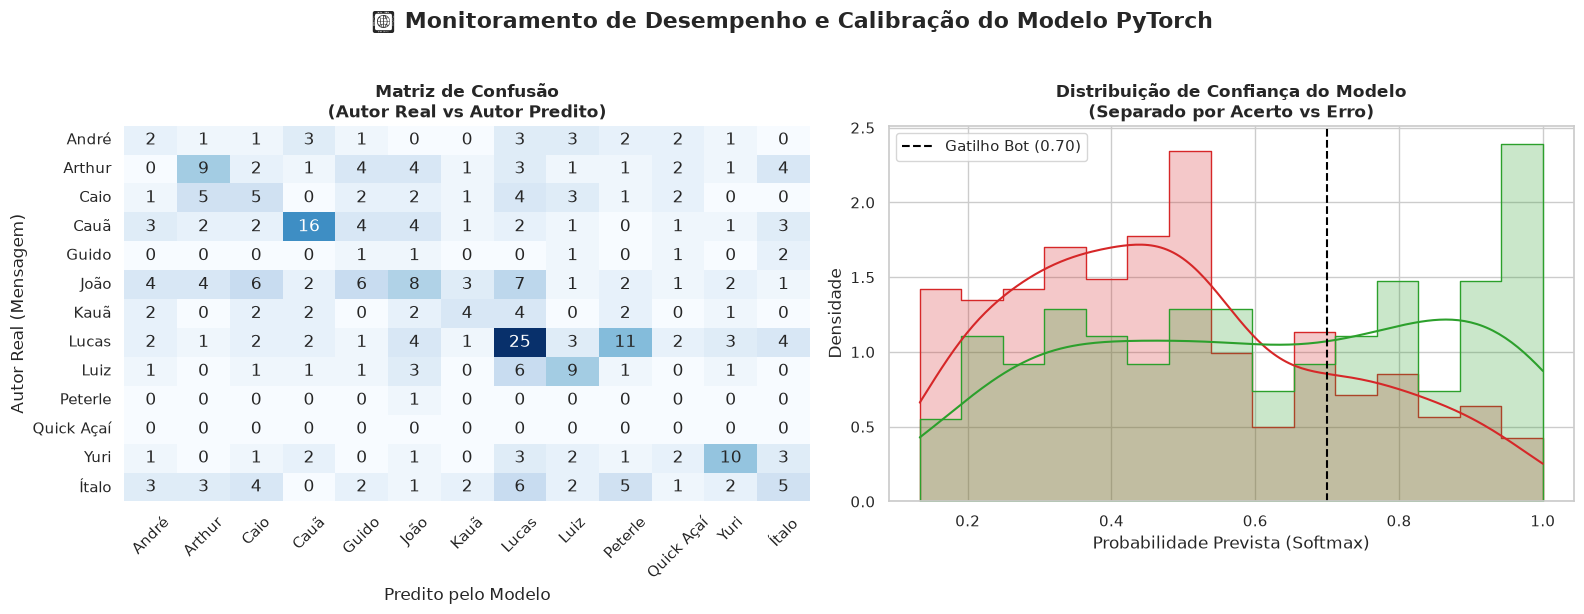

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "🎯 Monitoramento de Desempenho e Calibração do Modelo PyTorch",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

# --- Gráfico A: Matriz de Confusão em Produção ---
labels = sorted(list(set(y_real).union(set(y_pred))))
cm = confusion_matrix(y_real, y_pred, labels=labels)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title(
    "Matriz de Confusão\n(Autor Real vs Autor Predito)", fontweight="bold"
)
axes[0].set_xlabel("Predito pelo Modelo")
axes[0].set_ylabel("Autor Real (Mensagem)")
axes[0].tick_params(axis="x", rotation=45)

# --- Gráfico B: Calibração das Probabilidades (Softmax) ---
# Separa as probabilidades de acerto vs erro
df_prob = df_prev.copy()
df_prob["resultado"] = np.where(
    df_prob["autor_real"] == df_prob["autor_predito"], "Acerto", "Erro"
)

sns.histplot(
    data=df_prob,
    x="probabilidade",
    hue="resultado",
    element="step",
    stat="density",
    common_norm=False,
    bins=15,
    palette={"Acerto": "#2ca02c", "Erro": "#d62728"},
    ax=axes[1],
    kde=True,
)

axes[1].axvline(
    0.70,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Gatilho Bot (0.70)",
)
axes[1].set_title(
    "Distribuição de Confiança do Modelo\n(Separado por Acerto vs Erro)",
    fontweight="bold",
)
axes[1].set_xlabel("Probabilidade Prevista (Softmax)")
axes[1].set_ylabel("Densidade")
axes[1].legend()

plt.tight_layout()
plt.show()

In [81]:
from scipy import stats

df_calc = df_prev.copy()
df_calc["is_acerto"] = df_calc["autor_real"] == df_calc["autor_predito"]

proba_acertos = df_calc[df_calc["is_acerto"]]["probabilidade"]
proba_erros = df_calc[~df_calc["is_acerto"]]["probabilidade"]

# 2. A. Teste de Mann-Whitney U (Unilateral / Unidirectional: Acertos > Erros)
stat, p_value = stats.mannwhitneyu(
    proba_acertos, proba_erros, alternative="greater"
)

# 3. B. Effect Size: Correlação Rank-Biserial (r_rb)
# r_rb = 1 - (2 * U) / (n1 * n2)
n1 = len(proba_acertos)
n2 = len(proba_erros)
rank_biserial = 1 - (2 * stat) / (n1 * n2)

# Interpretador do Effect Size (Convenção de Cohen/Vargha-Delaney)
abs_r = abs(rank_biserial)
if abs_r < 0.14:
    efeito_txt = "Insignificante"
elif abs_r < 0.33:
    efeito_txt = "Pequeno"
elif abs_r < 0.47:
    efeito_txt = "Médio"
else:
    efeito_txt = "Grande / Forte"

In [82]:
# 4. Exibição Formal do Relatório
print("=" * 65)
print("EVIDÊNCIA ESTATÍSTICA DA CALIBRAÇÃO (MANN-WHITNEY U)")
print("=" * 65)
print(
    f"• Amostra: {n1} Acertos | {n2} Erros (Total: {n1 + n2} previsões)"
)
print(f"• Mediana Prob. (Acertos): {proba_acertos.median():.4f}")
print(f"• Mediana Prob. (Erros):   {proba_erros.median():.4f}")
print("-" * 65)
print("A. MANN-WHITNEY U TEST (H1: Prob(Acertos) > Prob(Erros))")
print(f"   • Estatística U: {stat:.2f}")
print(f"   • p-value:       {p_value:.4e}")

if p_value < 0.05:
    print(
        "   ✓ H0 Rejeitada: As probabilidades dos acertos SÃO estatisticamente "
        "maiores que as dos erros (p < 0.05)."
    )
else:
    print(
        "   ⚠️ H0 Não Rejeitada: Não há diferença estatisticamente significativa "
        "na confiança entre acertos e erros."
    )

print("\nB. EFFECT SIZE (Rank-Biserial Correlation)")
print(f"   • Tamanho do Efeito (r_rb): {rank_biserial:.4f}")
print(f"   • Classificação:           {efeito_txt}")
print("=" * 65)

EVIDÊNCIA ESTATÍSTICA DA CALIBRAÇÃO (MANN-WHITNEY U)
• Amostra: 94 Acertos | 244 Erros (Total: 338 previsões)
• Mediana Prob. (Acertos): 0.6113
• Mediana Prob. (Erros):   0.4627
-----------------------------------------------------------------
A. MANN-WHITNEY U TEST (H1: Prob(Acertos) > Prob(Erros))
   • Estatística U: 14807.00
   • p-value:       1.6808e-05
   ✓ H0 Rejeitada: As probabilidades dos acertos SÃO estatisticamente maiores que as dos erros (p < 0.05).

B. EFFECT SIZE (Rank-Biserial Correlation)
   • Tamanho do Efeito (r_rb): -0.2912
   • Classificação:           Pequeno


### Análise de Impostores vs Inocentes (Comportamento do Grupo e Doppelgängers)

In [83]:
df_imp = df_prev.copy()

# Flag de impostura: Autor Real != Autor Predito
df_imp["is_impostor"] = df_imp["autor_real"] != df_imp["autor_predito"]

# Totalizadores gerais
total_mensagens = len(df_imp)
total_impostores = df_imp["is_impostor"].sum()
total_legitimos = total_mensagens - total_impostores
taxa_impostura = (total_impostores / total_mensagens) * 100

print("=" * 60)
print("🎭 RESUMO GERAL DE IMPOSTURA E DYNAMICS DO GRUPO")
print("=" * 60)
print(f"• Total de Mensagens Analisadas:  {total_mensagens}")
print(f"• Identidades Confirmadas (Legítimas): {total_legitimos} ({100 - taxa_impostura:.2f}%)")
print(f"• Tentativas de Impostura (Doppelgängers): {total_impostores} ({taxa_impostura:.2f}%)")
print("-" * 60)

🎭 RESUMO GERAL DE IMPOSTURA E DYNAMICS DO GRUPO
• Total de Mensagens Analisadas:  338
• Identidades Confirmadas (Legítimas): 94 (27.81%)
• Tentativas de Impostura (Doppelgängers): 244 (72.19%)
------------------------------------------------------------


In [84]:
# A. Maiores Falsificadores/Impostores (Filtra só onde IS_IMPOSTOR == True)
df_casos_impostor = df_imp[df_imp["is_impostor"]]

top_falsificadores = (
    df_casos_impostor["autor_real"]
    .value_counts()
    .rename_axis("Membro")
    .reset_index(name="Vezes_Impostor")
)

# B. Maiores Vítimas (Quem teve o estilo de escrita "clonado")
top_clonados = (
    df_casos_impostor["autor_predito"]
    .value_counts()
    .rename_axis("Membro")
    .reset_index(name="Vezes_Clonado")
)

print("\n🏆 RANKING DOS MAIORES DOPPELGÄNGERS (Autor Real que simulou outro):")
print(top_falsificadores.head(5).to_string(index=False))

print("\n🎯 RANKING DOS ESTILOS MAIS IMITADOS (Autor Predito roubado):")
print(top_clonados.head(5).to_string(index=False))


🏆 RANKING DOS MAIORES DOPPELGÄNGERS (Autor Real que simulou outro):
Membro  Vezes_Impostor
  João              39
 Lucas              36
 Ítalo              31
Arthur              24
  Cauã              24

🎯 RANKING DOS ESTILOS MAIS IMITADOS (Autor Predito roubado):
 Membro  Vezes_Clonado
  Lucas             38
Peterle             26
   João             23
   Caio             21
  Guido             21


/tmp/ipykernel_337543/1104066453.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_337543/1104066453.py:69: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


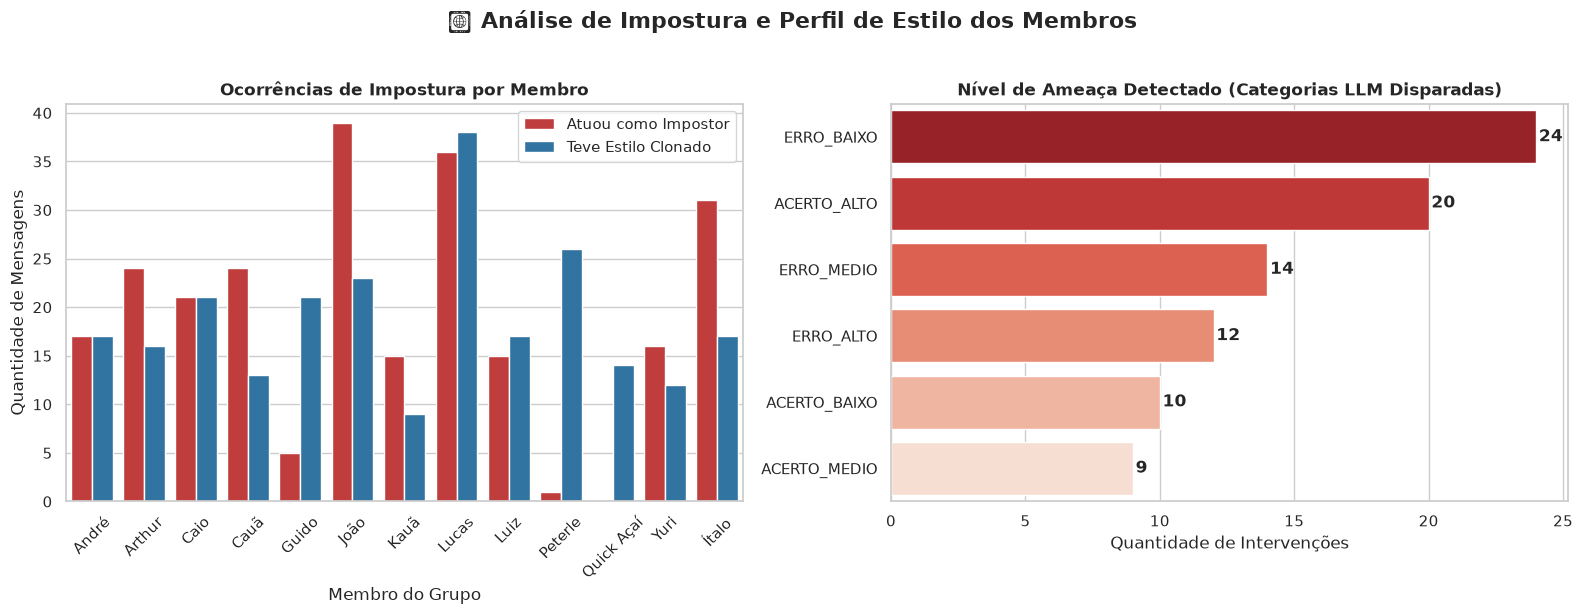

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "🎭 Análise de Impostura e Perfil de Estilo dos Membros",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

# --- Gráfico A: Top Falsificadores vs Top Clonados ---
df_comp_membros = pd.merge(
    top_falsificadores, top_clonados, on="Membro", how="outer"
).fillna(0)
df_comp_membros_melt = df_comp_membros.melt(
    id_vars="Membro",
    value_vars=["Vezes_Impostor", "Vezes_Clonado"],
    var_name="Tipo",
    value_name="Quantidade",
)
df_comp_membros_melt["Tipo"] = df_comp_membros_melt["Tipo"].replace(
    {"Vezes_Impostor": "Atuou como Impostor", "Vezes_Clonado": "Teve Estilo Clonado"}
)

sns.barplot(
    data=df_comp_membros_melt,
    x="Membro",
    y="Quantidade",
    hue="Tipo",
    palette={"Atuou como Impostor": "#d62728", "Teve Estilo Clonado": "#1f77b4"},
    ax=axes[0],
)
axes[0].set_title("Ocorrências de Impostura por Membro", fontweight="bold")
axes[0].set_xlabel("Membro do Grupo")
axes[0].set_ylabel("Quantidade de Mensagens")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="")

# --- Gráfico B: Categorias de Intervenção Efetuadas pelo Bot ---
if not df_prob.empty:
    dist_cat = df_prob["categoria"].value_counts().reset_index()
    dist_cat.columns = ["Categoria", "Quantidade"]

    # Ordena por severidade/frequência
    sns.barplot(
        data=dist_cat,
        y="Categoria",
        x="Quantidade",
        palette="Reds_r",
        ax=axes[1],
    )
    axes[1].set_title(
        "Nível de Ameaça Detectado (Categorias LLM Disparadas)", fontweight="bold"
    )
    axes[1].set_xlabel("Quantidade de Intervenções")
    axes[1].set_ylabel("")

    for index, value in enumerate(dist_cat["Quantidade"]):
        axes[1].text(
            value + 0.1, index, str(value), va="center", fontweight="bold"
        )
else:
    axes[1].text(
        0.5,
        0.5,
        "Sem dados na tabela mensagens_bot",
        ha="center",
        va="center",
    )

plt.tight_layout()
plt.show()

In [99]:
df_impostores_only = df_prev[
    df_prev["autor_real"] != df_prev["autor_predito"]
].copy()

labels_membros = sorted(
    list(
        set(df_prev["autor_real"]).union(
            set(df_prev["autor_predito"])
        )
    )
)

ct_doppel = pd.crosstab(
    df_impostores_only["autor_real"],
    df_impostores_only["autor_predito"],
    dropna=False,
).reindex(index=labels_membros, columns=labels_membros, fill_value=0)

/tmp/ipykernel_337543/1143496722.py:22: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


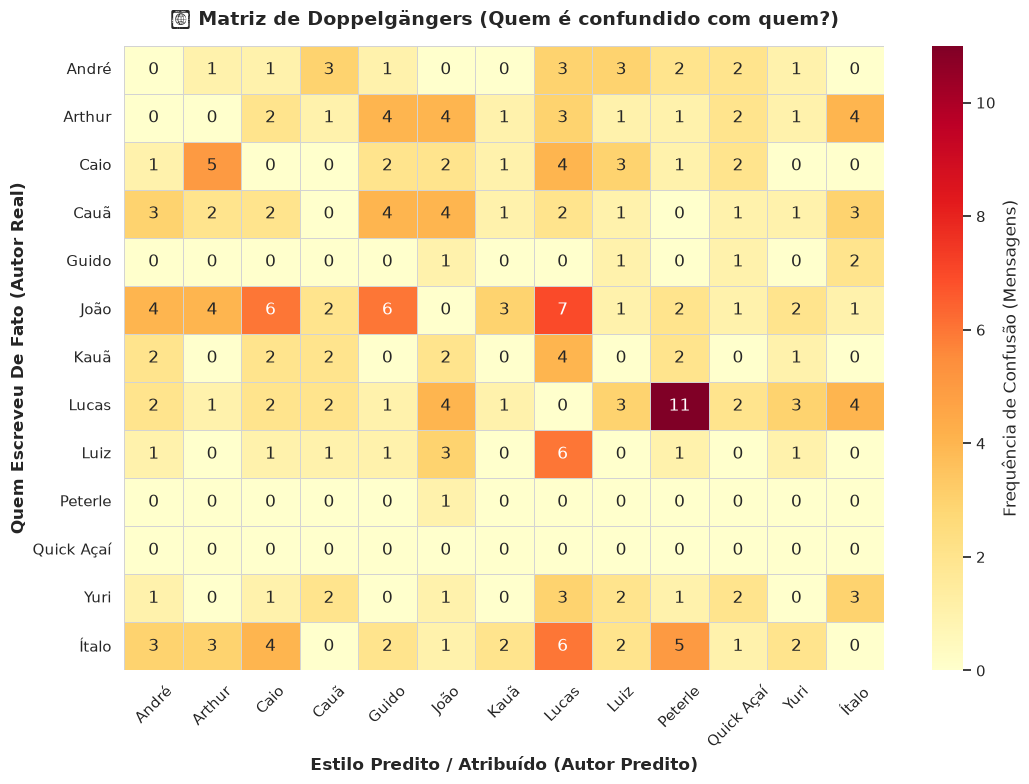

In [100]:
plt.figure(figsize=(11, 8))
sns.heatmap(
    ct_doppel,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    cbar_kws={"label": "Frequência de Confusão (Mensagens)"},
    linewidths=0.5,
    linecolor="lightgrey",
)

plt.title(
    "🎭 Matriz de Doppelgängers (Quem é confundido com quem?)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Estilo Predito / Atribuído (Autor Predito)", fontweight="bold")
plt.ylabel("Quem Escreveu De Fato (Autor Real)", fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_337543/2967827225.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


📊 DISTRIBUIÇÃO GLOBAL DE CATEGORIAS NA BASE DE PREVISÕES
              Categoria  Quantidade  Percentual
SEM_INTERVENCAO (<0.70)         249       73.67
             ERRO_BAIXO          24        7.10
            ACERTO_ALTO          20        5.92
             ERRO_MEDIO          14        4.14
              ERRO_ALTO          12        3.55
           ACERTO_BAIXO          10        2.96
           ACERTO_MEDIO           9        2.66
-----------------------------------------------------------------


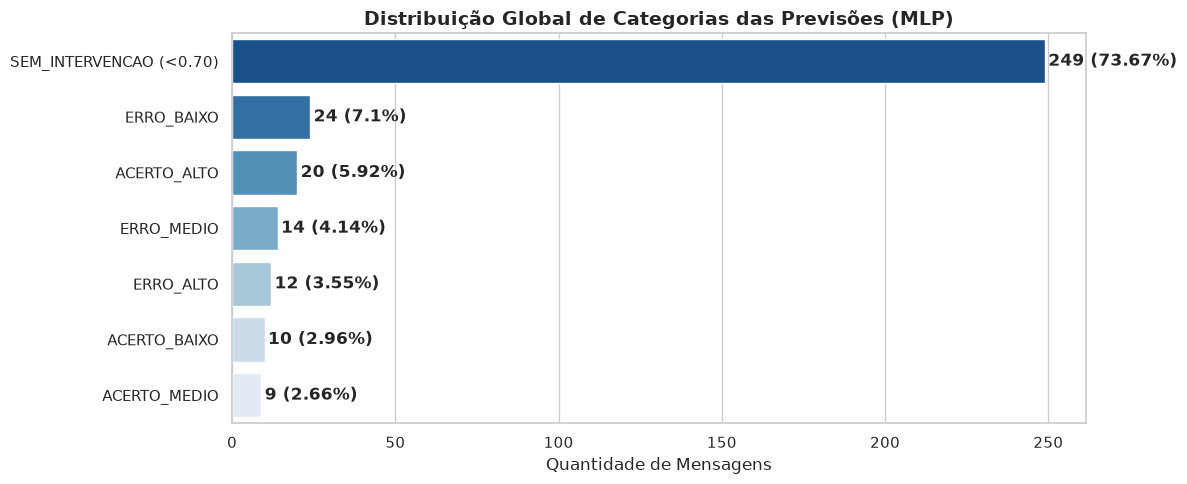

In [86]:
df_cat_full = df_prev.copy()
df_cat_full["categoria_geral"] = df_cat_full["categoria"].fillna(
    "SEM_INTERVENCAO (<0.70)"
)

dist_geral = df_cat_full["categoria_geral"].value_counts().reset_index()
dist_geral.columns = ["Categoria", "Quantidade"]
dist_geral["Percentual"] = (
    dist_geral["Quantidade"] / len(df_cat_full) * 100
).round(2)

print("=" * 65)
print("📊 DISTRIBUIÇÃO GLOBAL DE CATEGORIAS NA BASE DE PREVISÕES")
print("=" * 65)
print(dist_geral.to_string(index=False))
print("-" * 65)

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=dist_geral,
    x="Quantidade",
    y="Categoria",
    palette="Blues_r",
)
plt.title(
    "Distribuição Global de Categorias das Previsões (MLP)",
    fontweight="bold",
    fontsize=14,
)
plt.xlabel("Quantidade de Mensagens")
plt.ylabel("")

for index, row in dist_geral.iterrows():
    ax.text(
        row["Quantidade"] + 1,
        index,
        f"{row['Quantidade']} ({row['Percentual']}%)",
        va="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

### Monitoramento da LLM (Delivery do Bot) 

In [87]:
df_bot_analise = df_bot.copy()

df_bot_analise["num_caracteres"] = df_bot_analise["texto"].str.len()
df_bot_analise["num_palavras"] = df_bot_analise["texto"].apply(
    lambda x: len(str(x).split())
)

print("=" * 65)
print("🤖 RELATÓRIO DE MONITORAMENTO DO AGENTE LLM")
print("=" * 65)
print(f"• Total de textos gerados:      {len(df_bot_analise)}")
print(
    f"• Comprimento médio (palavras): {df_bot_analise['num_palavras'].mean():.1f} palavras"
)
print(
    f"• Comprimento médio (chars):    {df_bot_analise['num_caracteres'].mean():.1f} caracteres"
)
print(
    f"• Maior mensagem gerada:        {df_bot_analise['num_caracteres'].max()} caracteres ({df_bot_analise['num_palavras'].max()} palavras)"
)
print(
    f"• Menor mensagem gerada:        {df_bot_analise['num_caracteres'].min()} caracteres ({df_bot_analise['num_palavras'].min()} palavras)"
)
print("-" * 65)

🤖 RELATÓRIO DE MONITORAMENTO DO AGENTE LLM
• Total de textos gerados:      89
• Comprimento médio (palavras): 79.7 palavras
• Comprimento médio (chars):    464.1 caracteres
• Maior mensagem gerada:        786 caracteres (141 palavras)
• Menor mensagem gerada:        239 caracteres (31 palavras)
-----------------------------------------------------------------


/tmp/ipykernel_337543/3554863317.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_337543/3554863317.py:60: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


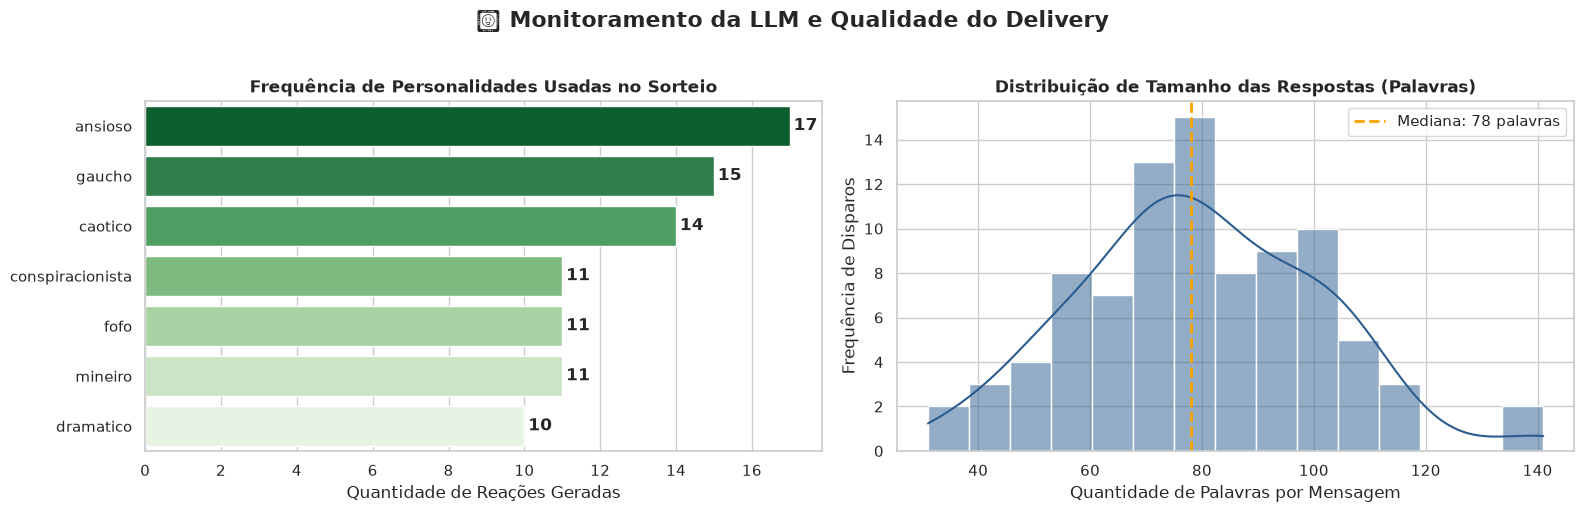

In [88]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "🤖 Monitoramento da LLM e Qualidade do Delivery",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

# --- Gráfico A: Diversidade de Personalidades Disparadas ---
pers_counts = df_bot_analise["personalidade"].value_counts().reset_index()
pers_counts.columns = ["Personalidade", "Frequencia"]

sns.barplot(
    data=pers_counts,
    x="Frequencia",
    y="Personalidade",
    palette="Greens_r",
    ax=axes[0],
)
axes[0].set_title(
    "Frequência de Personalidades Usadas no Sorteio", fontweight="bold"
)
axes[0].set_xlabel("Quantidade de Reações Geradas")
axes[0].set_ylabel("")

for index, row in pers_counts.iterrows():
    axes[0].text(
        row["Frequencia"] + 0.1,
        index,
        str(row["Frequencia"]),
        va="center",
        fontweight="bold",
    )

# --- Gráfico B: Distribuição do Comprimento das Mensagens (Palavras) ---
sns.histplot(
    data=df_bot_analise,
    x="num_palavras",
    bins=15,
    kde=True,
    color="#2b5c8f",
    ax=axes[1],
)
axes[1].axvline(
    df_bot_analise["num_palavras"].median(),
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {df_bot_analise['num_palavras'].median():.0f} palavras",
)
axes[1].set_title(
    "Distribuição de Tamanho das Respostas (Palavras)", fontweight="bold"
)
axes[1].set_xlabel("Quantidade de Palavras por Mensagem")
axes[1].set_ylabel("Frequência de Disparos")
axes[1].legend()

plt.tight_layout()
plt.show()

In [89]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

# ============================================================
# PREPARAÇÃO DOS DADOS (TÓPICO 4)
# ============================================================
df_bot_full = df_bot.copy()

# Cálculo de atributos de texto
df_bot_full["num_caracteres"] = df_bot_full["texto"].fillna("").str.len()
df_bot_full["num_palavras"] = df_bot_full["texto"].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else 0
)

# Merge com mensagens_previsoes para resgatar timestamps de latência
df_delivery = pd.merge(
    df_bot_full,
    df_prev[["id", "processado_em"]],
    left_on="previsao_id",
    right_on="id",
    how="left",
    suffixes=("", "_prev"),
)

# Cálculo de latências
df_delivery["processado_em"] = pd.to_datetime(
    df_delivery["processado_em"], utc=True
)
df_delivery["gerado_em"] = pd.to_datetime(df_delivery["gerado_em"], utc=True)
df_delivery["enviado_em"] = pd.to_datetime(df_delivery["enviado_em"], utc=True)
df_delivery["latencia_llm_seg"] = (
    df_delivery["gerado_em"] - df_delivery["processado_em"]
).dt.total_seconds()
df_delivery["latencia_delivery_seg"] = (
    df_delivery["enviado_em"] - df_delivery["gerado_em"]
).dt.total_seconds()

In [90]:
print("=" * 65)
print("📊 4.3 CONSISTÊNCIA DAS PERSONALIDADES E TAMANHO DE RESPOSTA")
print("=" * 65)

stats_persona = (
    df_bot_full.groupby("personalidade")
    .agg(
        total_gerado=("id", "count"),
        media_palavras=("num_palavras", "mean"),
        std_palavras=("num_palavras", "std"),
        min_palavras=("num_palavras", "min"),
        max_palavras=("num_palavras", "max"),
    )
    .reset_index()
)

stats_persona["media_palavras"] = stats_persona["media_palavras"].round(1)
stats_persona["std_palavras"] = (
    stats_persona["std_palavras"].fillna(0).round(1)
)

print(stats_persona.to_string(index=False))
print("-" * 65)

# ============================================================
# 4.4 INTEGRIDADE DAS GERAÇÕES
# ============================================================
total_geracoes = len(df_bot_full)
textos_nulos = df_bot_full["texto"].isnull().sum()
textos_vazios = (df_bot_full["num_caracteres"] == 0).sum()
status_counts = df_bot_full["status"].value_counts().to_dict()

print("\n" + "=" * 65)
print("🔍 4.4 INTEGRIDADE DAS GERAÇÕES DA LLM")
print("=" * 65)
print(f"• Total de registros na mensagens_bot: {total_geracoes}")
print(f"• Textos Nulos / Vazios:              {textos_nulos + textos_vazios}")
print(f"• Distribuição de Status de Envio:     {status_counts}")
print("-" * 65)

# ============================================================
# 4.5 DELIVERY (EVOLUTION API)
# ============================================================
print("\n" + "=" * 65)
print("🚀 4.5 PERFORMANCE DE DELIVERY E LATÊNCIAS")
print("=" * 65)

df_enviados = df_delivery.dropna(subset=["enviado_em"])
worker_3_ativo = not df_enviados.empty

if worker_3_ativo:
    taxa_envio = (len(df_enviados) / total_geracoes) * 100
    p50_deliv = df_enviados["latencia_delivery_seg"].median()
    p95_deliv = df_enviados["latencia_delivery_seg"].quantile(0.95)

    print(f"• Worker 3 Status:         ATIVO")
    print(
        f"• Taxa de Envio Efetuado:  {taxa_envio:.2f}% ({len(df_enviados)}/{total_geracoes})"
    )
    print(f"• Latência LLM ➔ Wpp (p50): {p50_deliv:.2f}s")
    print(f"• Latência LLM ➔ Wpp (p95): {p95_deliv:.2f}s")
else:
    print("ℹ️ Worker 3 ainda não está ativo nesta execução.")
    print("   • Mensagens permanecem com status 'PENDENTE_ENVIO'.")
    print("   • Análise de latência de disparo será habilitada no deploy.")

print("=" * 65)

📊 4.3 CONSISTÊNCIA DAS PERSONALIDADES E TAMANHO DE RESPOSTA
   personalidade  total_gerado  media_palavras  std_palavras  min_palavras  max_palavras
         ansioso            17            62.6          14.6            43           106
         caotico            14            65.7          26.9            31           141
conspiracionista            11            85.5          10.8            70           104
       dramatico            10            91.6          12.2            75           109
            fofo            11            77.5          22.0            38           118
          gaucho            15            94.8          19.8            69           139
         mineiro            11            88.6          13.1            71           108
-----------------------------------------------------------------

🔍 4.4 INTEGRIDADE DAS GERAÇÕES DA LLM
• Total de registros na mensagens_bot: 89
• Textos Nulos / Vazios:              0
• Distribuição de Status de Envio:     {'

/tmp/ipykernel_337543/2943102764.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_337543/2943102764.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_337543/2943102764.py:87: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


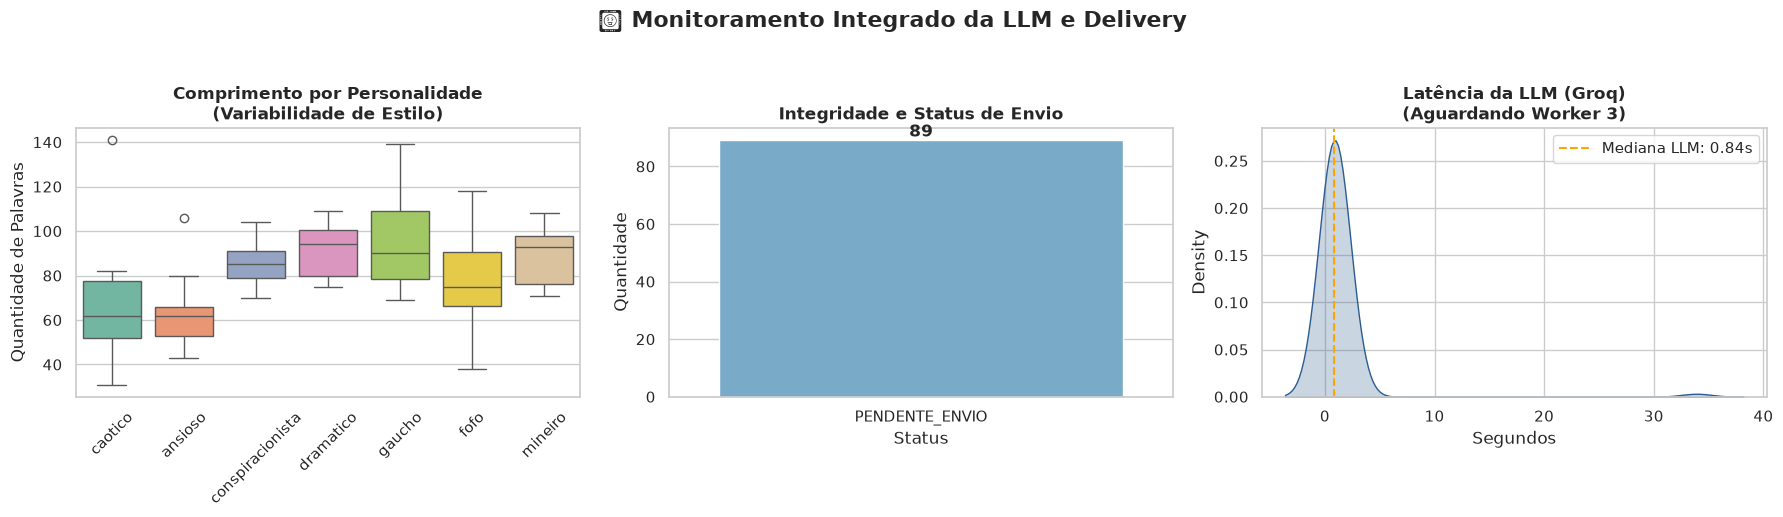

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "🤖 Monitoramento Integrado da LLM e Delivery",
    fontsize=16,
    fontweight="bold",
    y=1.03,
)

# --- Gráfico 1: Variação de Tamanho de Palavras por Personalidade ---
sns.boxplot(
    data=df_bot_full,
    x="personalidade",
    y="num_palavras",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title(
    "Comprimento por Personalidade\n(Variabilidade de Estilo)",
    fontweight="bold",
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Quantidade de Palavras")
axes[0].tick_params(axis="x", rotation=45)

# --- Gráfico 2: Integridade e Status das Mensagens ---
sns.countplot(
    data=df_bot_full,
    x="status",
    palette="Blues_r",
    ax=axes[1],
)
axes[1].set_title("Integridade e Status de Envio", fontweight="bold")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Quantidade")

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontweight="bold",
        )

# --- Gráfico 3: Latência LLM vs Delivery (Se ativo) ---
if worker_3_ativo:
    sns.kdeplot(
        data=df_delivery["latencia_llm_seg"],
        label="Latência LLM (Groq)",
        color="green",
        fill=True,
        ax=axes[2],
    )
    sns.kdeplot(
        data=df_enviados["latencia_delivery_seg"],
        label="Latência Delivery (Wpp)",
        color="red",
        fill=True,
        ax=axes[2],
    )
    axes[2].set_title(
        "Distribuição de Latências (Segundos)", fontweight="bold"
    )
    axes[2].set_xlabel("Segundos")
    axes[2].legend()
else:
    sns.kdeplot(
        data=df_delivery["latencia_llm_seg"],
        color="#2b5c8f",
        fill=True,
        ax=axes[2],
    )
    axes[2].axvline(
        df_delivery["latencia_llm_seg"].median(),
        color="orange",
        linestyle="--",
        label=f"Mediana LLM: {df_delivery['latencia_llm_seg'].median():.2f}s",
    )
    axes[2].set_title(
        "Latência da LLM (Groq)\n(Aguardando Worker 3)", fontweight="bold"
    )
    axes[2].set_xlabel("Segundos")
    axes[2].legend()

plt.tight_layout()
plt.show()

###  Drift e Mudança Temporal de Comportamento 

In [92]:
import json
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

df_drift = df_prev.copy()

# Garantir conversão do timestamp de processamento
df_drift["processado_em"] = pd.to_datetime(
    df_drift["processado_em"], utc=True
)


# Extração segura dos campos do JSON de features
def extrair_feature(val, key):
    if isinstance(val, str):
        try:
            val = json.loads(val)
        except Exception:
            return None
    if isinstance(val, dict):
        return val.get(key)
    return None


df_drift["dia_semana"] = df_drift["features"].apply(
    lambda x: extrair_feature(x, "dia")
)
df_drift["hora_dia"] = df_drift["features"].apply(
    lambda x: extrair_feature(x, "hora")
)

# Caso o JSON não tenha os dados completos, extrai direto do timestamp
if df_drift["hora_dia"].isnull().any():
    df_drift["hora_dia"] = df_drift["hora_dia"].fillna(
        df_drift["processado_em"].dt.hour
    )

# Agrupamento semanal para cálculo de Data Drift
df_drift["semana_ano"] = df_drift[
    "processado_em"
].dt.to_period("W").dt.to_timestamp()

f1_semanal = []
semanas_unicas = sorted(df_drift["semana_ano"].unique())

for sem in semanas_unicas:
    sub_df = df_drift[df_drift["semana_ano"] == sem]
    if len(sub_df) > 0:
        score = f1_score(
            sub_df["autor_real"],
            sub_df["autor_predito"],
            average="macro",
            zero_division=0,
        )
        f1_semanal.append(
            {
                "semana": sem.strftime("%Y-%m-%d"),
                "macro_f1": score,
                "qtd_mensagens": len(sub_df),
            }
        )

df_f1_semanal = pd.DataFrame(f1_semanal)

/tmp/ipykernel_337543/1683172939.py:41: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ].dt.to_period("W").dt.to_timestamp()


In [93]:
print("=" * 65)
print("📈 EVOLUÇÃO SEMANAL DO MACRO F1 (DATA DRIFT TRACKING)")
print("=" * 65)
print(df_f1_semanal.to_string(index=False))
print("-" * 65)

📈 EVOLUÇÃO SEMANAL DO MACRO F1 (DATA DRIFT TRACKING)
    semana  macro_f1  qtd_mensagens
2026-09-21  0.226965            338
-----------------------------------------------------------------


/tmp/ipykernel_337543/3861697678.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_337543/3861697678.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_337543/3861697678.py:72: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9203 (\N{HOURGLASS WITH FLOWING SAND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


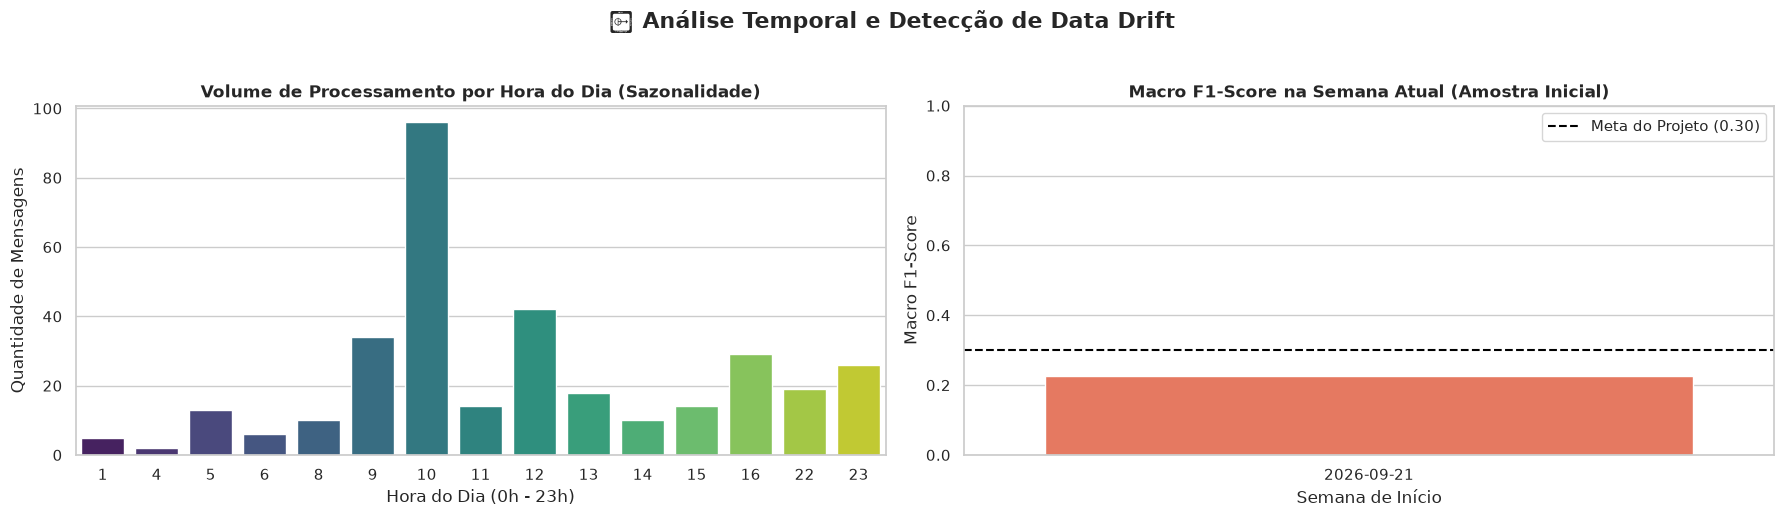

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(
    "⏳ Análise Temporal e Detecção de Data Drift",
    fontsize=16,
    fontweight="bold",
    y=1.03,
)

# --- Gráfico A: Volume de Mensagens por Hora do Dia ---
sns.countplot(
    data=df_drift,
    x="hora_dia",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title(
    "Volume de Processamento por Hora do Dia (Sazonalidade)",
    fontweight="bold",
)
axes[0].set_xlabel("Hora do Dia (0h - 23h)")
axes[0].set_ylabel("Quantidade de Mensagens")

# --- Gráfico B: Evolução Semanal do Macro F1 (Linha de Drift) ---
if len(df_f1_semanal) > 1:
    sns.lineplot(
        data=df_f1_semanal,
        x="semana",
        y="macro_f1",
        marker="o",
        linewidth=2.5,
        color="#d62728",
        ax=axes[1],
    )
    axes[1].axhline(
        0.3,
        color="black",
        linestyle="--",
        label="Meta do Projeto (Macro F1 = 0.30)",
    )
    axes[1].set_title(
        "Evolução Temporal do Macro F1-Score (Acompanhamento de Drift)",
        fontweight="bold",
    )
    axes[1].set_xlabel("Semana de Produção")
    axes[1].set_ylabel("Macro F1-Score")
    axes[1].set_ylim(0, 1.0)
    axes[1].legend()
    axes[1].tick_params(axis="x", rotation=45)
else:
    # Caso haja apenas 1 semana de histórico inicial
    sns.barplot(
        data=df_f1_semanal,
        x="semana",
        y="macro_f1",
        palette="Reds_r",
        ax=axes[1],
    )
    axes[1].axhline(
        0.3,
        color="black",
        linestyle="--",
        label="Meta do Projeto (0.30)",
    )
    axes[1].set_title(
        "Macro F1-Score na Semana Atual (Amostra Inicial)", fontweight="bold"
    )
    axes[1].set_xlabel("Semana de Início")
    axes[1].set_ylabel("Macro F1-Score")
    axes[1].set_ylim(0, 1.0)
    axes[1].legend()

plt.tight_layout()
plt.show()

In [95]:
df_drift_analise = df_prev.copy()

df_drift_analise["processado_em"] = pd.to_datetime(
    df_drift_analise["processado_em"], utc=True
)
df_drift_analise["semana"] = (
    df_drift_analise["processado_em"].dt.to_period("W").dt.to_timestamp()
)
df_drift_analise["comprimento_char"] = df_drift_analise["mensagem"].str.len()

semanas_disponiveis = sorted(df_drift_analise["semana"].unique())
qtd_semanas = len(semanas_disponiveis)

/tmp/ipykernel_337543/3908611013.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_drift_analise["processado_em"].dt.to_period("W").dt.to_timestamp()


In [96]:
print("=" * 65)
print("⏳ RELATÓRIO DE MONITORAMENTO DE DATA DRIFT")
print("=" * 65)
print(f"• Semanas observadas no histórico: {qtd_semanas}")
for s in semanas_disponiveis:
    qtd_msg = (df_drift_analise["semana"] == s).sum()
    print(f"   - Semana {s.strftime('%Y-%m-%d')}: {qtd_msg} mensagens")
print("-" * 65)

# ------------------------------------------------------------
# COMPARAÇÃO ESTATÍSTICA (Apenas se houver 2 ou mais semanas)
# ------------------------------------------------------------
if qtd_semanas >= 2:
    sem_anterior = semanas_disponiveis[-2]
    sem_atual = semanas_disponiveis[-1]

    df_anterior = df_drift_analise[df_drift_analise["semana"] == sem_anterior]
    df_atual = df_drift_analise[df_drift_analise["semana"] == sem_atual]

    # 1. Teste Kolmogorov-Smirnov para o Comprimento do Texto (Feature Drift)
    ks_stat, ks_pvalue = stats.ks_2samp(
        df_anterior["comprimento_char"].dropna(),
        df_atual["comprimento_char"].dropna(),
    )

    print("\n🔬 TESTES ESTATÍSTICOS DE DRIFT ENTRE AS DUAS ÚLTIMAS SEMANAS:")
    print(
        f"  (Comparando {sem_anterior.strftime('%Y-%m-%d')} vs {sem_atual.strftime('%Y-%m-%d')})"
    )
    print("-" * 65)
    print("A. Teste Kolmogorov-Smirnov (KS-Test no Comprimento de Texto)")
    print(f"   • Estatística KS: {ks_stat:.4f}")
    print(f"   • p-value:        {ks_pvalue:.4e}")

    if ks_pvalue < 0.05:
        print(
            "   ⚠️ ALERT: Houve mudança estatisticamente significativa no tamanho das mensagens! (Feature Drift)"
        )
    else:
        print(
            "   ✓ ESTÁVEL: A distribuição do tamanho das mensagens permanece consistente (p >= 0.05)."
        )

    # 2. Teste Chi-Quadrado para Proporção de Autores Reais (Concept/Covariate Drift)
    contingency_tab = pd.crosstab(
        df_drift_analise["semana"], df_drift_analise["autor_real"]
    )
    chi2_stat, chi2_pvalue, dof, _ = stats.chi2_contingency(contingency_tab)

    print("\nB. Teste Chi-Quadrado (Proporção de Atividade por Membro)")
    print(f"   • Estatística Chi2: {chi2_stat:.4f}")
    print(f"   • p-value:          {chi2_pvalue:.4e}")

    if chi2_pvalue < 0.05:
        print(
            "   ⚠️ ALERT: A proporção de envio de mensagens entre os membros mudou significativamente!"
        )
    else:
        print(
            "   ✓ ESTÁVEL: O padrão de engajamento entre os membros está estatisticamente estável."
        )

else:
    print("\nℹ️ MODO BASELINE (1ª Semana de Produção):")
    print(
        "   • Acúmulo de dados insuficiente para testes de hipóteses bilaterais entre janelas."
    )
    print(
        "   • Os dados da semana atual foram registrados como o baseline oficial de produção."
    )

print("=" * 65)

⏳ RELATÓRIO DE MONITORAMENTO DE DATA DRIFT
• Semanas observadas no histórico: 1
   - Semana 2026-09-21: 338 mensagens
-----------------------------------------------------------------

ℹ️ MODO BASELINE (1ª Semana de Produção):
   • Acúmulo de dados insuficiente para testes de hipóteses bilaterais entre janelas.
   • Os dados da semana atual foram registrados como o baseline oficial de produção.


/tmp/ipykernel_337543/3187407611.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(
/tmp/ipykernel_337543/3187407611.py:66: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


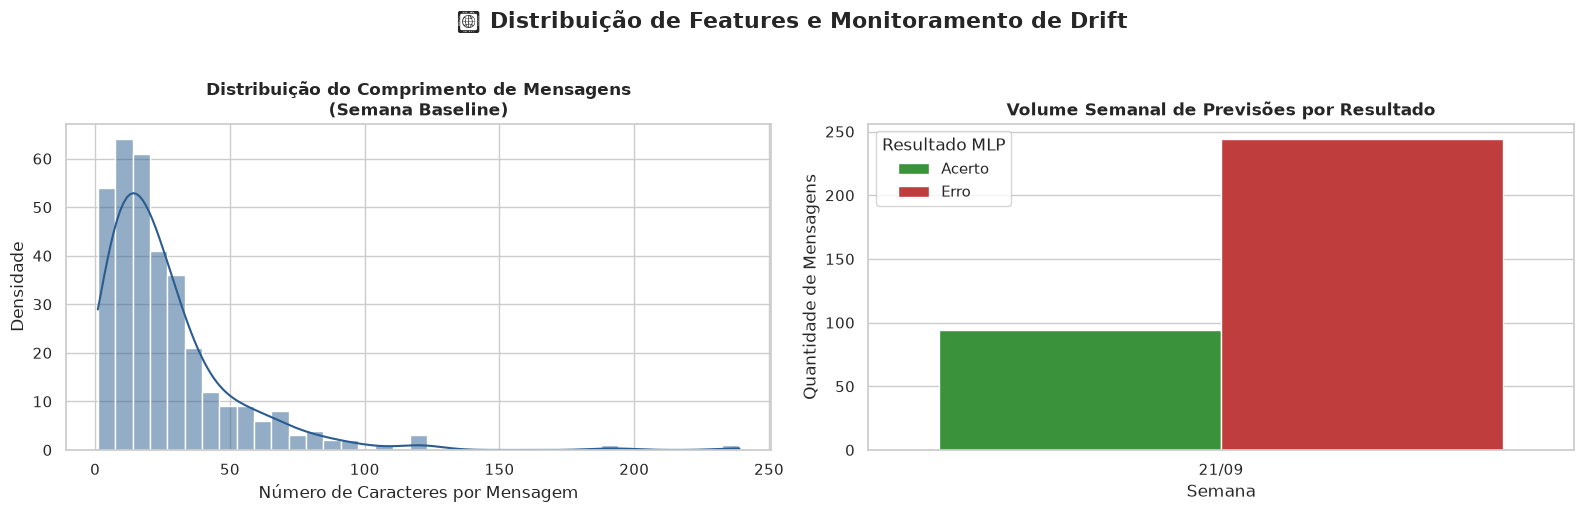

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "📊 Distribuição de Features e Monitoramento de Drift",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

# --- Gráfico 1: Densidade do Tamanho das Mensagens por Semana ---
if qtd_semanas >= 2:
    sns.kdeplot(
        data=df_drift_analise,
        x="comprimento_char",
        hue="semana",
        common_norm=False,
        fill=True,
        palette="Set1",
        ax=axes[0],
    )
    axes[0].set_title(
        "Distribuição do Comprimento de Mensagens\n(Comparação Semanal)",
        fontweight="bold",
    )
else:
    sns.histplot(
        data=df_drift_analise,
        x="comprimento_char",
        kde=True,
        color="#2b5c8f",
        ax=axes[0],
    )
    axes[0].set_title(
        "Distribuição do Comprimento de Mensagens\n(Semana Baseline)",
        fontweight="bold",
    )

axes[0].set_xlabel("Número de Caracteres por Mensagem")
axes[0].set_ylabel("Densidade")

# --- Gráfico 2: Evolução das Intervenções (Acerto vs Erro) ---
df_drift_analise["is_acerto"] = np.where(
    df_drift_analise["autor_real"] == df_drift_analise["autor_predito"],
    "Acerto",
    "Erro",
)

sns.countplot(
    data=df_drift_analise,
    x="semana",
    hue="is_acerto",
    palette={"Acerto": "#2ca02c", "Erro": "#d62728"},
    ax=axes[1],
)
axes[1].set_title(
    "Volume Semanal de Previsões por Resultado", fontweight="bold"
)
axes[1].set_xlabel("Semana")
axes[1].set_ylabel("Quantidade de Mensagens")
axes[1].legend(title="Resultado MLP")

# Formatação das datas no eixo X
axes[1].set_xticklabels(
    [s.strftime("%d/%m") for s in semanas_disponiveis], rotation=0
)

plt.tight_layout()
plt.show()